# Market Timing Performance Analysis

Evaluates the BUY/HOLD/SELL market timing strategy results from the SQLite database.

**Metrics covered:**
- Cumulative timing return (long / neutral / short) vs. buy-and-hold benchmarks
- Sharpe ratio, max drawdown, annualised return
- Decision hit rate: did BUY/SELL predict the correct next-day direction?
- Analyst signal hit rate: Bullish/Bearish directional accuracy per analyst

**DB**: `/Users/maximilianheil/OMSCS/data/deepfund.db`

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

# ── DB path ────────────────────────────────────────────────────────────────
# Must be set BEFORE importing decision_making modules (DB_PATH is read at import time)
os.environ["DB_PATH"] = "/Users/maximilianheil/OMSCS/data/deepfund.db"

# ── Python path ────────────────────────────────────────────────────────────
project_root = Path().absolute().parent.parent
decision_making_dir = project_root / "decision_making"
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(decision_making_dir))
os.chdir(decision_making_dir)  # needed for ama_data relative paths

# ── Standard imports ───────────────────────────────────────────────────────
import importlib
import json
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl

# ── Reload project modules to pick up latest code ──────────────────────────
import decision_making.analysis.performance as perf_module
import decision_making.analysis.queries as query_module

importlib.reload(perf_module)
importlib.reload(query_module)

from decision_making.analysis.performance import (
    calculate_annualized_return,
    calculate_buy_hold_benchmark,
    calculate_decision_hit_rate,
    calculate_max_drawdown,
    calculate_portfolio_benchmark,
    calculate_sharpe_ratio,
    calculate_signal_hit_rate,
    calculate_timing_performance,
)
from decision_making.analysis.queries import (
    check_data_quality,
    get_all_decisions,
    get_all_signals,
    get_decision_summary,
    get_experiment_metadata,
    get_signal_summary,
)
from decision_making.database.sqlite_helper import SQLiteDB

# ── Plot style ─────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 10

C = {
    "TSLA": "#E31E24",
    "BTC": "#F7931A",
    "benchmark": "#888888",
    "Buy": "#28A745",
    "Sell": "#DC3545",
    "Hold": "#6C757D",
    "Bullish": "#90EE90",
    "Bearish": "#F08080",
    "Neutral": "#FFE4B5",
}

print(f"Working dir : {os.getcwd()}")
print(f"DB_PATH     : {os.environ['DB_PATH']}")
print("Setup complete.")

Working dir : /Users/maximilianheil/OMSCS/finmmeval-task3-2026 copy/decision_making
DB_PATH     : /Users/maximilianheil/OMSCS/data/deepfund.db
Setup complete.


/opt/homebrew/Caskroom/miniconda/base/envs/finmmeval/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Experiment

In [2]:
db = SQLiteDB()

# ── List all experiments in the DB ─────────────────────────────────────────
import sqlite3

conn = sqlite3.connect(os.environ["DB_PATH"])
conn.row_factory = sqlite3.Row
cur = conn.cursor()
cur.execute("""
    SELECT c.exp_name, c.tickers, c.llm_model,
           COUNT(DISTINCT p.id) as days,
           MIN(p.trading_date) as start_date,
           MAX(p.trading_date) as end_date,
           COUNT(DISTINCT d.id) as decisions
    FROM config c
    LEFT JOIN portfolio p ON p.config_id = c.id
    LEFT JOIN decision d ON d.portfolio_id = p.id
    GROUP BY c.id ORDER BY c.exp_name
""")
experiments = [dict(r) for r in cur.fetchall()]
conn.close()

print(f"Found {len(experiments)} experiment(s):")
for e in experiments:
    print(
        f"  {e['exp_name']:35s}  {e['days']:>4} days  "
        f"{e['start_date'][:10]} → {e['end_date'][:10]}  "
        f"{e['decisions']:>5} decisions  model={e['llm_model']}"
    )

Found 1 experiment(s):
  tesla_btc_baseline                    361 days  2024-08-02 → 2026-01-09    722 decisions  model=gpt-4.1-nano


In [10]:
# ── Select experiment ──────────────────────────────────────────────────────
EXP_NAME = "abelation_company_news_enhanced_2"  # ← change to compare a different config

config_id = db.get_config_id_by_name(EXP_NAME)
assert config_id, f"Experiment '{EXP_NAME}' not found in DB"

meta = get_experiment_metadata(db, config_id)
tickers = json.loads(meta["tickers"]) if isinstance(meta["tickers"], str) else meta["tickers"]
start_date = meta["start_date"]
end_date = meta["end_date"]

print(f"Experiment : {meta['exp_name']}")
print(f"Tickers    : {tickers}")
print(f"Model      : {meta['llm_model']}")
print(f"Period     : {start_date.date()} → {end_date.date()} ({meta['trading_days']} trading days)")

quality = check_data_quality(db, config_id)
print(f"\nData quality: {quality['total_decisions']} decisions, {quality['total_signals']} signals")

Experiment : abelation_company_news_enhanced_2
Tickers    : ['TSLA', 'BTC']
Model      : gpt-4.1-nano
Period     : 2024-08-02 → 2026-01-09 (526 trading days)

Data quality: 722 decisions, 2782 signals


## 3. Decision Overview

In [11]:
decisions = get_all_decisions(db, config_id)
if decisions["trading_date"].dtype == pl.Utf8:
    decisions = decisions.with_columns(pl.col("trading_date").str.to_datetime())

print(f"Total decisions: {len(decisions)}")
print()
print(decisions.group_by(["ticker", "action"]).agg(pl.len().alias("count")).sort(["ticker", "action"]))

Total decisions: 722

shape: (6, 3)
┌────────┬────────┬───────┐
│ ticker ┆ action ┆ count │
│ ---    ┆ ---    ┆ ---   │
│ str    ┆ str    ┆ u32   │
╞════════╪════════╪═══════╡
│ BTC    ┆ Buy    ┆ 169   │
│ BTC    ┆ Hold   ┆ 95    │
│ BTC    ┆ Sell   ┆ 97    │
│ TSLA   ┆ Buy    ┆ 170   │
│ TSLA   ┆ Hold   ┆ 97    │
│ TSLA   ┆ Sell   ┆ 94    │
└────────┴────────┴───────┘


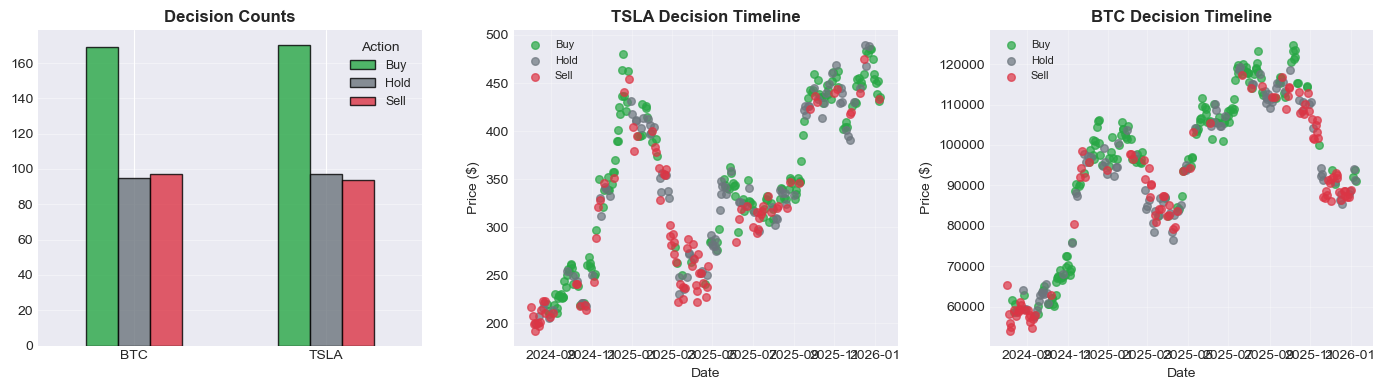

In [12]:
# Decision distribution & timeline
fig, axes = plt.subplots(1, len(tickers) + 1, figsize=(14, 4))
action_order = ["Buy", "Hold", "Sell"]

# -- bar chart: counts per ticker/action --
ax_bar = axes[0]
summary = decisions.group_by(["ticker", "action"]).agg(pl.len().alias("count")).to_pandas()
pivot = summary.pivot(index="ticker", columns="action", values="count").fillna(0)
for col in action_order:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[action_order]
pivot.plot(kind="bar", ax=ax_bar, color=[C[a] for a in action_order], alpha=0.8, edgecolor="black")
ax_bar.set_title("Decision Counts", fontweight="bold")
ax_bar.set_xlabel("")
ax_bar.set_xticklabels(ax_bar.get_xticklabels(), rotation=0)
ax_bar.legend(title="Action", fontsize=9)
ax_bar.grid(axis="y", alpha=0.4)

# -- timeline per ticker --
for i, ticker in enumerate(tickers):
    ax = axes[i + 1]
    td = decisions.filter(pl.col("ticker") == ticker).to_pandas()
    for action in action_order:
        sub = td[td["action"] == action]
        if len(sub):
            ax.scatter(sub["trading_date"], sub["price"], c=C[action], s=30, alpha=0.7, label=action, zorder=3)
    ax.set_title(f"{ticker} Decision Timeline", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Market Timing Performance

For each decision on date T:
- **BUY** (long) → captures next-day asset return
- **SELL** (short) → captures **negative** of next-day asset return
- **HOLD** (neutral) → zero contribution

Cumulative return = compounded product of daily timing returns.

In [13]:
timing_results = {}
for ticker in tickers:
    df = calculate_timing_performance(db, config_id, ticker)
    if df is not None and len(df) > 0:
        timing_results[ticker] = df
        print(f"{ticker}: {len(df)} decisions, final cumulative return = {df['cumulative_return_pct'][-1]:.2f}%")
    else:
        print(f"{ticker}: no decisions with price data")

TSLA: 361 decisions, final cumulative return = -23.53%
BTC: 361 decisions, final cumulative return = -18.53%


In [14]:
# Benchmarks
benchmarks = {}
for ticker in tickers:
    try:
        benchmarks[ticker] = calculate_buy_hold_benchmark(ticker, start_date, end_date)
    except Exception as e:
        print(f"Benchmark error {ticker}: {e}")

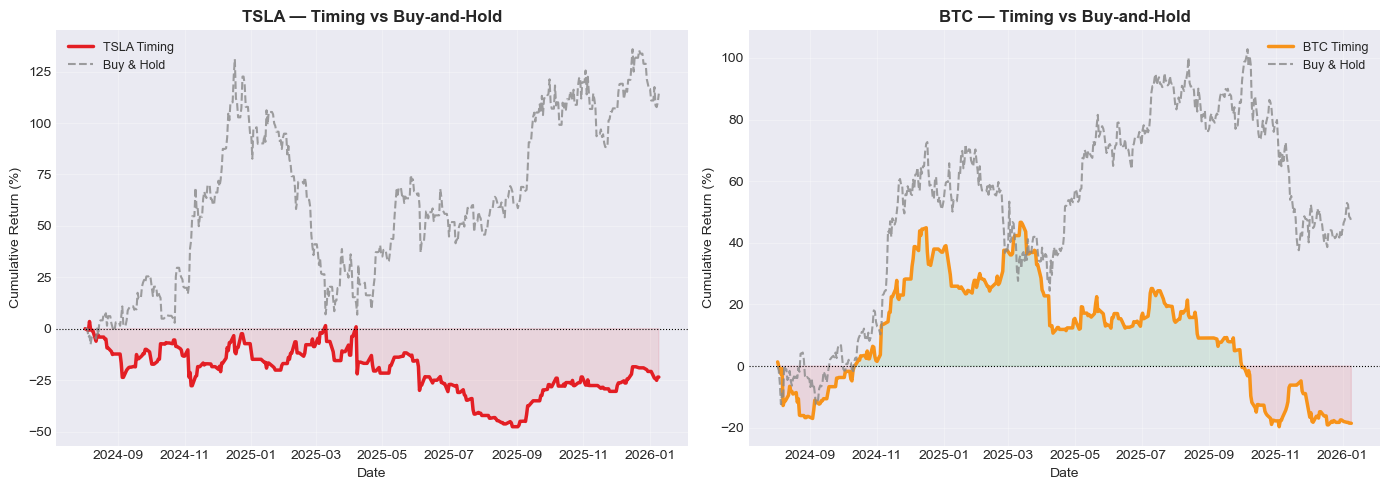

In [15]:
# Plot: timing return vs buy-and-hold per ticker
fig, axes = plt.subplots(1, len(tickers), figsize=(14, 5), sharey=False)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    color = C.get(ticker, "steelblue")

    if ticker in timing_results:
        perf = timing_results[ticker].to_pandas()
        ax.plot(perf["trading_date"], perf["cumulative_return_pct"], color=color, linewidth=2.5, label=f"{ticker} Timing")
        ax.fill_between(
            perf["trading_date"],
            0,
            perf["cumulative_return_pct"],
            where=perf["cumulative_return_pct"] >= 0,
            color=C["Buy"],
            alpha=0.12,
        )
        ax.fill_between(
            perf["trading_date"],
            0,
            perf["cumulative_return_pct"],
            where=perf["cumulative_return_pct"] < 0,
            color=C["Sell"],
            alpha=0.12,
        )

    if ticker in benchmarks:
        bm = benchmarks[ticker].to_pandas()
        ax.plot(
            bm["date"],
            bm["cumulative_return_pct"],
            color=C["benchmark"],
            linewidth=1.5,
            linestyle="--",
            alpha=0.8,
            label="Buy & Hold",
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{ticker} — Timing vs Buy-and-Hold", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Return (%)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ── Key metrics table ──────────────────────────────────────────────────────
rows = []

for ticker in tickers:
    # Timing strategy
    if ticker in timing_results:
        perf = timing_results[ticker]
        ret_series = perf["timing_return_pct"]
        total_ret = perf["cumulative_return_pct"][-1]
        num_days = (end_date - start_date).days
        sharpe = calculate_sharpe_ratio(ret_series)
        max_dd, _, _ = calculate_max_drawdown(pl.Series([(1 + r / 100) for r in perf["timing_return_pct"].cum_sum().to_list()]))
        ann_ret = calculate_annualized_return(total_ret, num_days)
        n_buy = (perf["action"] == "Buy").sum()
        n_sell = (perf["action"] == "Sell").sum()
        n_hold = (perf["action"] == "Hold").sum()
        rows.append({
            "Strategy": f"{ticker} Timing",
            "Buy": int(n_buy),
            "Hold": int(n_hold),
            "Sell": int(n_sell),
            "Total Return %": round(total_ret, 2),
            "Ann. Return %": round(ann_ret, 2),
            "Sharpe": round(sharpe, 3),
            "Max DD %": round(max_dd, 2),
        })

    # Buy-and-hold benchmark
    if ticker in benchmarks:
        bm = benchmarks[ticker]
        bm_ret = bm["cumulative_return_pct"][-1]
        bm_returns = bm["cumulative_return_pct"].diff()
        bm_sharpe = calculate_sharpe_ratio(bm_returns.drop_nulls())
        bm_dd, _, _ = calculate_max_drawdown(bm["portfolio_value"])
        bm_ann = calculate_annualized_return(float(bm_ret), (end_date - start_date).days)
        rows.append({
            "Strategy": f"{ticker} Buy-Hold",
            "Buy": "-",
            "Hold": "-",
            "Sell": "-",
            "Total Return %": round(float(bm_ret), 2),
            "Ann. Return %": round(bm_ann, 2),
            "Sharpe": round(bm_sharpe, 3),
            "Max DD %": round(bm_dd, 2),
        })

metrics_df = pd.DataFrame(rows).set_index("Strategy")
print("=" * 80)
print("PERFORMANCE METRICS")
print("=" * 80)
print(metrics_df.to_string())
print("=" * 80)

PERFORMANCE METRICS
               Buy Hold Sell  Total Return %  Ann. Return %  Sharpe  Max DD %
Strategy                                                                     
TSLA Timing    170   97   94          -23.53         -17.01  -0.134    -53.70
TSLA Buy-Hold    -    -    -          114.29          69.87   0.673    -53.77
BTC Timing     169   95   97          -18.53         -13.28  -0.299    -40.57
BTC Buy-Hold     -    -    -           47.07          30.76   0.421    -32.15


## 5. Decision Hit Rate

**Hit** = BUY decision followed by price increase next day, or SELL followed by price decrease.  
Evaluated at 1-day and 5-day lookahead.

In [11]:
hit_1d = calculate_decision_hit_rate(db, config_id, lookahead_days=1)
hit_5d = calculate_decision_hit_rate(db, config_id, lookahead_days=5)

if len(hit_1d) > 0:
    print("Decision hit rate — 1-day lookahead:")
    print(hit_1d.sort(["ticker", "action"]))
    print()
    print("Decision hit rate — 5-day lookahead:")
    print(hit_5d.sort(["ticker", "action"]))
else:
    print("No BUY/SELL decisions found — hit rate cannot be computed.")

Decision hit rate — 1-day lookahead:
shape: (4, 5)
┌────────┬────────┬─────────────────┬──────┬──────────────┐
│ ticker ┆ action ┆ total_decisions ┆ hits ┆ hit_rate_pct │
│ ---    ┆ ---    ┆ ---             ┆ ---  ┆ ---          │
│ str    ┆ str    ┆ u32             ┆ i32  ┆ f64          │
╞════════╪════════╪═════════════════╪══════╪══════════════╡
│ BTC    ┆ Buy    ┆ 43              ┆ 22   ┆ 51.162791    │
│ BTC    ┆ Sell   ┆ 17              ┆ 10   ┆ 58.823529    │
│ TSLA   ┆ Buy    ┆ 35              ┆ 15   ┆ 42.857143    │
│ TSLA   ┆ Sell   ┆ 39              ┆ 8    ┆ 20.512821    │
└────────┴────────┴─────────────────┴──────┴──────────────┘

Decision hit rate — 5-day lookahead:
shape: (4, 5)
┌────────┬────────┬─────────────────┬──────┬──────────────┐
│ ticker ┆ action ┆ total_decisions ┆ hits ┆ hit_rate_pct │
│ ---    ┆ ---    ┆ ---             ┆ ---  ┆ ---          │
│ str    ┆ str    ┆ u32             ┆ i32  ┆ f64          │
╞════════╪════════╪═════════════════╪══════╪═════════════

In [ ]:
if len(hit_1d) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, (hit_df, label) in zip(axes, [(hit_1d, "1-Day"), (hit_5d, "5-Day")]):
        df = hit_df.to_pandas()
        df["label"] = df["ticker"] + " " + df["action"]
        bar_colors = [C.get(a, "gray") for a in df["action"]]

        bars = ax.barh(df["label"], df["hit_rate_pct"], color=bar_colors, alpha=0.8, edgecolor="black")
        ax.axvline(50, color="black", linestyle="--", linewidth=1, alpha=0.6, label="Random (50%)")

        # Annotate with counts
        for bar, (_, row) in zip(bars, df.iterrows()):
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{row['hits']}/{row['total_decisions']}",
                va="center",
                fontsize=8,
            )

        ax.set_xlim(0, 110)
        ax.set_xlabel("Hit Rate (%)")
        ax.set_title(f"Decision Hit Rate — {label} Lookahead", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6. Analyst Signal Hit Rate

**Bullish** signal is a hit when the asset price rises the next day.  
**Bearish** signal is a hit when the asset price falls the next day.

In [ ]:
sig_hit_1d = calculate_signal_hit_rate(db, config_id, lookahead_days=1)
sig_hit_5d = calculate_signal_hit_rate(db, config_id, lookahead_days=5)

if len(sig_hit_1d) > 0:
    print("Signal hit rate — 1-day lookahead:")
    print(sig_hit_1d.sort(["analyst", "ticker", "signal"]))
else:
    print("No Bullish/Bearish signals found — signal hit rate cannot be computed.")

In [ ]:
if len(sig_hit_1d) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (hit_df, label) in zip(axes, [(sig_hit_1d, "1-Day"), (sig_hit_5d, "5-Day")]):
        df = hit_df.to_pandas()
        df["label"] = df["analyst"] + "\n" + df["ticker"] + " " + df["signal"]
        bar_colors = [C.get(s, "gray") for s in df["signal"]]

        bars = ax.barh(df["label"], df["hit_rate_pct"], color=bar_colors, alpha=0.8, edgecolor="black")
        ax.axvline(50, color="black", linestyle="--", linewidth=1, alpha=0.6, label="Random (50%)")

        for bar, (_, row) in zip(bars, df.iterrows()):
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{row['hits']}/{row['total_signals']}",
                va="center",
                fontsize=8,
            )

        ax.set_xlim(0, 115)
        ax.set_xlabel("Hit Rate (%)")
        ax.set_title(f"Analyst Signal Hit Rate — {label} Lookahead", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Heatmap: analyst × ticker hit rate (1-day)
if len(sig_hit_1d) > 0:
    df = sig_hit_1d.to_pandas()
    pivot = df.pivot_table(index="analyst", columns=["ticker", "signal"], values="hit_rate_pct")

    fig, ax = plt.subplots(figsize=(10, max(3, len(pivot) * 0.8)))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{t}\n{s}" for t, s in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(
                    j,
                    i,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color="white" if val < 30 or val > 70 else "black",
                )

    plt.colorbar(im, ax=ax, label="Hit Rate (%)")
    ax.set_title("Analyst Signal Hit Rate Heatmap (1-day lookahead)", fontweight="bold")
    plt.tight_layout()
    plt.show()

## 7. Signal Distribution

In [ ]:
try:
    signals = get_all_signals(db, config_id)
    if signals["trading_date"].dtype == pl.Utf8:
        signals = signals.with_columns(pl.col("trading_date").str.to_datetime())

    print(f"Total signals: {len(signals)}")
    summary = get_signal_summary(db, config_id)
    print(summary.sort(["analyst", "ticker", "signal"]))
except Exception as e:
    print(f"No signal data: {e}")
    signals = None

In [ ]:
if signals is not None and len(signals) > 0:
    analysts = signals["analyst"].unique().to_list()
    signal_order = ["Bullish", "Neutral", "Bearish"]

    fig, axes = plt.subplots(1, len(tickers), figsize=(14, 4))
    if len(tickers) == 1:
        axes = [axes]

    for ax, ticker in zip(axes, tickers):
        tick_sigs = signals.filter(pl.col("ticker") == ticker).to_pandas()
        counts = (
            tick_sigs
            .groupby(["analyst", "signal"])
            .size()
            .reset_index(name="count")
            .pivot(index="analyst", columns="signal", values="count")
            .fillna(0)
        )
        for col in signal_order:
            if col not in counts.columns:
                counts[col] = 0
        counts = counts[[c for c in signal_order if c in counts.columns]]
        counts.plot(kind="bar", ax=ax, color=[C[s] for s in counts.columns], alpha=0.85, edgecolor="black")
        ax.set_title(f"{ticker} — Signal Distribution by Analyst", fontweight="bold")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        ax.legend(title="Signal", fontsize=9)
        ax.grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.show()

## 8. Multi-Experiment Comparison

If you have run multiple configs over the same date range, this cell compares their timing performance side-by-side.

In [ ]:
# Add experiment names to compare here
COMPARE_EXPERIMENTS = [EXP_NAME]  # extend with other exp_names once available
COMPARE_TICKER = tickers[0]  # pick one ticker for the comparison

fig, ax = plt.subplots(figsize=(14, 5))
comp_rows = []

for exp in COMPARE_EXPERIMENTS:
    cid = db.get_config_id_by_name(exp)
    if not cid:
        continue
    df = calculate_timing_performance(db, cid, COMPARE_TICKER)
    if df is None or len(df) == 0:
        continue

    perf = df.to_pandas()
    ax.plot(perf["trading_date"], perf["cumulative_return_pct"], linewidth=2, label=exp)

    total_ret = perf["cumulative_return_pct"].iloc[-1]
    sharpe = calculate_sharpe_ratio(df["timing_return_pct"])
    meta_e = get_experiment_metadata(db, cid)
    n_days = meta_e["trading_days"]
    ann_ret = calculate_annualized_return(total_ret, (meta_e["end_date"] - meta_e["start_date"]).days)
    hit = calculate_decision_hit_rate(db, cid, lookahead_days=1)
    avg_hit = hit["hit_rate_pct"].mean() if len(hit) > 0 else float("nan")

    comp_rows.append({
        "Experiment": exp,
        "Ticker": COMPARE_TICKER,
        "Trading Days": n_days,
        "Total Return %": round(total_ret, 2),
        "Ann. Return %": round(ann_ret, 2),
        "Sharpe": round(sharpe, 3),
        "Avg Hit Rate %": round(avg_hit, 1) if not np.isnan(avg_hit) else "n/a",
    })

# Add buy-and-hold reference
if COMPARE_TICKER in benchmarks:
    bm = benchmarks[COMPARE_TICKER].to_pandas()
    ax.plot(
        bm["date"],
        bm["cumulative_return_pct"],
        color=C["benchmark"],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label=f"{COMPARE_TICKER} Buy-Hold",
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title(f"{COMPARE_TICKER} — Experiment Comparison", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if comp_rows:
    print()
    print(pd.DataFrame(comp_rows).set_index("Experiment").to_string())

## 9. Summary

In [ ]:
print("=" * 70)
print(f"EXPERIMENT  : {EXP_NAME}")
print(f"PERIOD      : {start_date.date()} → {end_date.date()}")
print(f"TICKERS     : {', '.join(tickers)}")
print(f"MODEL       : {meta['llm_model']}")
print("=" * 70)
print()
print(metrics_df.to_string())
print()
if len(hit_1d) > 0:
    print("Decision hit rate (1-day):")
    print(hit_1d[["ticker", "action", "total_decisions", "hits", "hit_rate_pct"]].to_pandas().to_string(index=False))
    print()
if len(sig_hit_1d) > 0:
    print("Signal hit rate (1-day):")
    print(sig_hit_1d[["analyst", "ticker", "signal", "total_signals", "hits", "hit_rate_pct"]].to_pandas().to_string(index=False))